# Household Power Consumption — Clustering Analysis

This notebook clusters households/time-periods based on power consumption behavior using KMeans.

**Pipeline:** Load → Clean → Handle Outliers → Feature Engineering → Correlation/Skew Check → Scale → Choose k (Elbow + Silhouette) → Fit KMeans → Evaluate → Profile Clusters → Visualize (PCA) → Interpret

Compared to the original version, this notebook adds: consistent outlier handling across all features, time-based feature engineering instead of dropping Date/Time, multicollinearity handling, skew checking, silhouette-based k selection, full cluster evaluation metrics, and cluster profiling/interpretation.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## 1. Load Data

Update `DATA_PATH` to point to your local copy of `household_power_consumption.txt`
(originally the path was hardcoded to a specific Windows user folder — using a variable makes this portable).

In [8]:
DATA_PATH = 'household_power_consumption.txt'  # <-- update this path if needed

df = pd.read_csv(r'C:\Users\Mario\OneDrive\Desktop\SummerTraining\HOUSEHOLD POWER CONSUMPTION\household_power_consumption.txt', sep=';', low_memory=False, na_values=['?'])
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [9]:
df.shape

(2075259, 9)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


In [11]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


## 2. Initial Data Quality Check

In [12]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [13]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 0
Shape after dropping duplicates: (2075259, 9)


## 3. Missing Value Handling

Filling all numeric columns once, consistently (the original notebook filled `Global_active_power`
twice — once on its own, then again inside a loop over all columns — which was redundant).

In [14]:
numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

df[numeric_cols].isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

## 4. Outlier Detection & Treatment (all numeric columns)

The original notebook only IQR-clipped `Global_active_power`. KMeans uses Euclidean distance, so
outliers in *any* feature can distort the clusters — so we apply the same treatment consistently
across every numeric feature.

In [15]:
def iqr_clip(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    return series.clip(lower=lower, upper=upper), n_outliers

for col in numeric_cols:
    df[col], n_out = iqr_clip(df[col])
    print(f"{col}: clipped {n_out} outlier values")

Global_active_power: clipped 96742 outlier values
Global_reactive_power: clipped 42234 outlier values
Voltage: clipped 54737 outlier values
Global_intensity: clipped 100961 outlier values
Sub_metering_1: clipped 195084 outlier values
Sub_metering_2: clipped 77151 outlier values
Sub_metering_3: clipped 0 outlier values


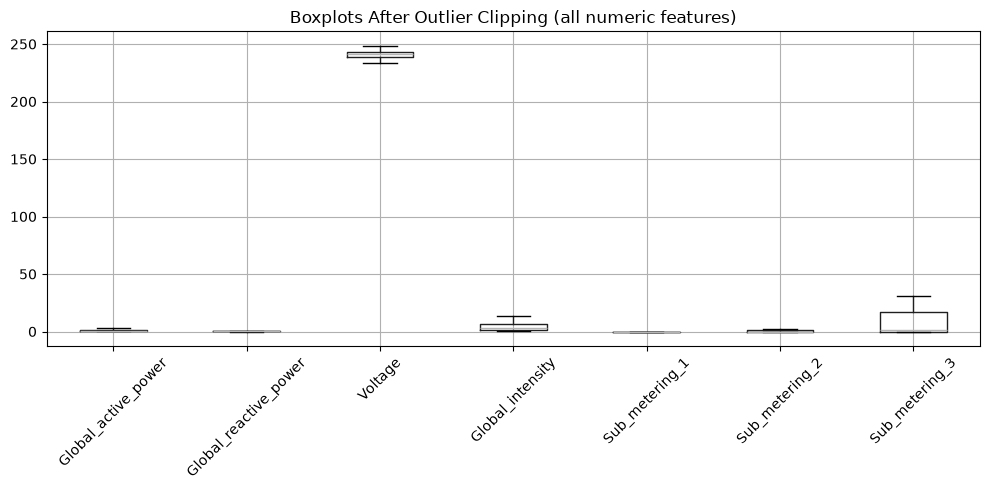

In [16]:
plt.figure(figsize=(10, 5))
df[numeric_cols].boxplot(rot=45)
plt.title('Boxplots After Outlier Clipping (all numeric features)')
plt.tight_layout()
plt.show()

## 5. Feature Engineering — Time Features

The original notebook dropped `Date` and `Time` entirely. For power-consumption data, *when*
usage happens is usually one of the most informative signals (e.g. morning/evening peaks, weekday
vs weekend). Instead of discarding it, we parse it into numeric features KMeans can use.

In [17]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

df['Hour'] = df['Datetime'].dt.hour
df['DayOfWeek'] = df['Datetime'].dt.dayofweek     # 0 = Monday
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

df = df.drop(columns=['Date', 'Time'])
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Hour,DayOfWeek,IsWeekend
0,3.335,0.408,234.84,13.9,0.0,1.0,17.0,2006-12-16 17:24:00,17,5,1
1,3.335,0.408,233.63,13.9,0.0,1.0,16.0,2006-12-16 17:25:00,17,5,1
2,3.335,0.408,233.29,13.9,0.0,2.0,17.0,2006-12-16 17:26:00,17,5,1
3,3.335,0.408,233.74,13.9,0.0,1.0,17.0,2006-12-16 17:27:00,17,5,1
4,3.335,0.408,235.68,13.9,0.0,1.0,17.0,2006-12-16 17:28:00,17,5,1


## 6. Correlation Analysis & Multicollinearity Check

Highly correlated features (e.g. `Global_active_power` and `Global_intensity` are known to be
almost perfectly correlated in this dataset) can dominate the distance metric KMeans relies on.
We inspect the correlation matrix and automatically drop one feature from any pair correlated
above 0.95.

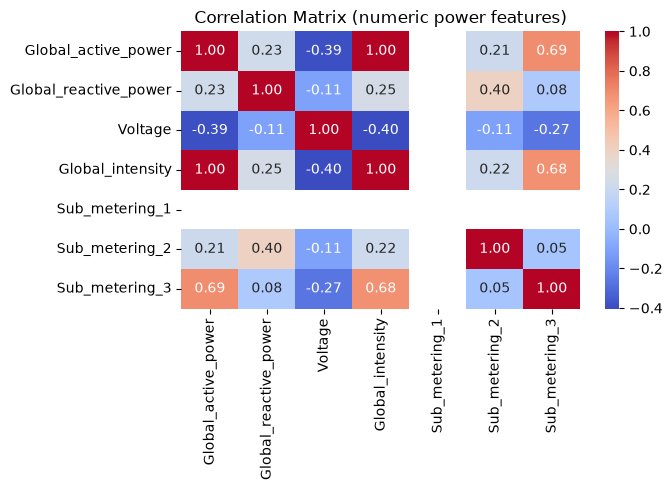

In [18]:
corr_cols = numeric_cols  # correlation among the raw power features only (not the time features)
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (numeric power features)')
plt.tight_layout()
plt.show()

In [19]:
# Automatically flag one feature from any pair correlated above the threshold
threshold = 0.95
to_drop = set()
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c1, c2 = corr_cols[i], corr_cols[j]
        if abs(corr_matrix.loc[c1, c2]) > threshold:
            print(f"High correlation ({corr_matrix.loc[c1, c2]:.3f}) between {c1} and {c2} -> dropping {c2}")
            to_drop.add(c2)

feature_cols = [c for c in numeric_cols if c not in to_drop] + ['Hour', 'DayOfWeek', 'IsWeekend']
print("\nFinal feature set for clustering:", feature_cols)

High correlation (0.999) between Global_active_power and Global_intensity -> dropping Global_intensity

Final feature set for clustering: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Hour', 'DayOfWeek', 'IsWeekend']


## 7. Distribution / Skew Check

`StandardScaler` centers and scales but does not fix skew. Since power-consumption data is
typically right-skewed, we check skewness and apply a `log1p` transform to heavily skewed
features (|skew| > 1) before scaling.

In [20]:
skew_vals = df[feature_cols].skew().sort_values(ascending=False)
print(skew_vals)

skewed_cols = skew_vals[abs(skew_vals) > 1].index.tolist()
print("\nColumns to log-transform:", skewed_cols)

df_model = df[feature_cols].copy()
for col in skewed_cols:
    df_model[col] = np.log1p(df_model[col] - df_model[col].min() + 1e-6)  # shift to keep values non-negative

Sub_metering_2           1.473784
Global_active_power      1.051001
IsWeekend                0.950502
Global_reactive_power    0.817568
Sub_metering_3           0.729267
DayOfWeek                0.001123
Sub_metering_1           0.000000
Hour                    -0.000203
Voltage                 -0.183980
dtype: float64

Columns to log-transform: ['Sub_metering_2', 'Global_active_power']


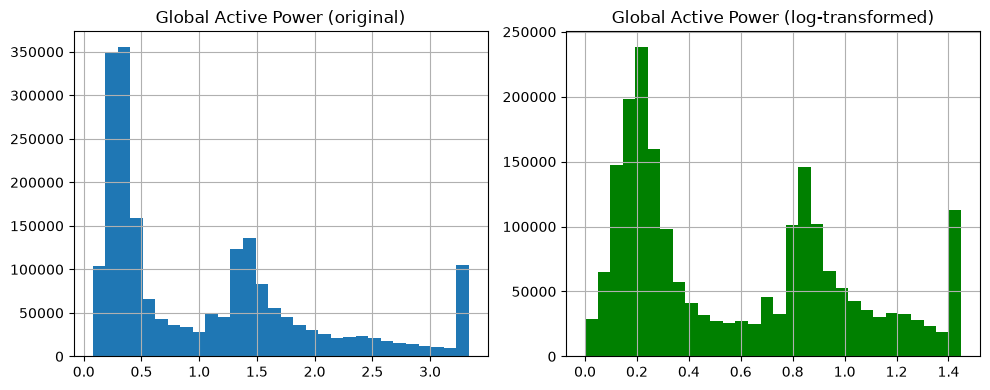

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Global_active_power'].hist(bins=30, ax=axes[0])
axes[0].set_title('Global Active Power (original)')
df_model['Global_active_power'].hist(bins=30, ax=axes[1], color='green') if 'Global_active_power' in skewed_cols else axes[1].set_title('Not log-transformed (skew <= 1)')
if 'Global_active_power' in skewed_cols:
    axes[1].set_title('Global Active Power (log-transformed)')
plt.tight_layout()
plt.show()

## 8. Scaling

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)
X_scaled.shape

(2075259, 9)

## 9. Choosing the Number of Clusters (k)

Relying on the elbow method alone is subjective — the "bend" is often ambiguous. We pair it with
the **silhouette score** (higher is better, range -1 to 1) across the same range of k, and use
both together to choose k. `random_state` is fixed in every run so the curves are reproducible.

In [ ]:
k_range = range(2, 9)
wcss = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={silhouette_scores[-1]:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), wcss, 'bx-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('WCSS')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouette_scores, 'go-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"\nk with highest silhouette score: {best_k}")
print("Cross-check this against the elbow plot and pick the k that makes sense for both before finalizing.")

**Choose your final k below.** Default is the silhouette-recommended value from above — override
`FINAL_K` manually if the elbow plot suggests a different, more interpretable value.

In [ ]:
FINAL_K = best_k  # <-- override with a specific integer if you prefer a different k after inspecting both plots
print("Using k =", FINAL_K)

## 10. Fit Final KMeans Model

In [ ]:
kmeans = KMeans(n_clusters=FINAL_K, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = kmeans_labels
df['Cluster'].value_counts().sort_index()

## 11. Cluster Evaluation

Three complementary metrics on the *fitted* model (not just during k-selection):
- **Silhouette score** — cohesion vs separation (higher is better)
- **Davies-Bouldin index** — average similarity between clusters (lower is better)
- **Calinski-Harabasz index** — ratio of between/within cluster dispersion (higher is better)

In [ ]:
sil = silhouette_score(X_scaled, kmeans_labels)
db = davies_bouldin_score(X_scaled, kmeans_labels)
ch = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"Silhouette Score:        {sil:.4f}  (higher is better, max 1.0)")
print(f"Davies-Bouldin Index:    {db:.4f}  (lower is better)")
print(f"Calinski-Harabasz Index: {ch:.1f}  (higher is better)")

In [ ]:
# Per-sample silhouette plot — reveals weak/negative-silhouette points that an average score can hide.
# NOTE: computing silhouette_samples on the full dataset can be slow/memory-heavy for very large data;
# subsample if needed.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=min(20000, len(X_scaled)), replace=False)
sample_silhouette_values = silhouette_samples(X_scaled[sample_idx], kmeans_labels[sample_idx])
sample_labels = kmeans_labels[sample_idx]

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in range(FINAL_K):
    cluster_vals = np.sort(sample_silhouette_values[sample_labels == i])
    y_upper = y_lower + len(cluster_vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_vals), str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', label=f'Average silhouette = {sil:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Per-Sample Silhouette Plot (20k-point sample)')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Cluster Profiling

A clustering result is only useful if you can describe what each cluster *means*. Here we look
at the average feature values per cluster and cluster sizes.

In [ ]:
cluster_profile = df.groupby('Cluster')[feature_cols].mean()
cluster_profile['count'] = df['Cluster'].value_counts().sort_index()
cluster_profile

In [ ]:
plt.figure(figsize=(9, 5))
sns.heatmap(
    df.groupby('Cluster')[feature_cols].mean().apply(lambda x: (x - x.mean()) / x.std()),
    annot=True, cmap='coolwarm', fmt='.2f'
)
plt.title('Cluster Profiles (z-scored feature means per cluster)')
plt.tight_layout()
plt.show()

**Interpretation template** — fill this in based on the table/heatmap above:
- Cluster 0: ...
- Cluster 1: ...
- Cluster 2: ...
- (etc.)

For example, a cluster with high `Global_active_power`, high `Hour` values clustered around evening,
and low `IsWeekend` might represent weekday-evening high-usage periods.

## 13. PCA Visualization

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by 2 components: {:.1f}%".format(pca.explained_variance_ratio_.sum() * 100))

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', s=5, alpha=0.5)
plt.title(f"Clusters after PCA (k={FINAL_K})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

## 14. Conclusion & Next Steps

**Summary of what changed vs. the original notebook:**
- Fixed `random_state` everywhere for reproducibility (elbow loop previously had none)
- Outlier clipping (IQR) applied to *all* numeric features, not just `Global_active_power`
- `Date`/`Time` converted into `Hour`, `DayOfWeek`, `IsWeekend` features instead of being dropped
- Automatic detection and removal of highly correlated (redundant) features before clustering
- Skew check with optional log-transform before scaling
- k chosen using both the elbow method *and* silhouette score, not elbow alone
- Full evaluation: silhouette score, Davies-Bouldin index, Calinski-Harabasz index, per-sample silhouette plot
- Cluster profiling (group means, z-scored heatmap) so clusters have an actual interpretation
- Removed the redundant double `fillna` on `Global_active_power`

**Possible further improvements (not implemented here):**
- Resample to hourly/daily aggregates before clustering — minute-level readings (~2M rows) may
  cluster mostly on noise; daily household "usage profiles" could be more analytically meaningful.
- Try DBSCAN or hierarchical clustering and compare against KMeans results.
- Engineer a "unmetered consumption" feature: `Global_active_power*1000/60 - (Sub_metering_1 + Sub_metering_2 + Sub_metering_3)`,
  a known useful derived feature for this dataset.
